Найдено неустойчивых мод: 1
Собственные числа: [19.88134807+0.j]

Проверка проекций:
Мода 19.88+0.00j: Abs амплитуда до = 7.01e+00, после = 8.94e-12


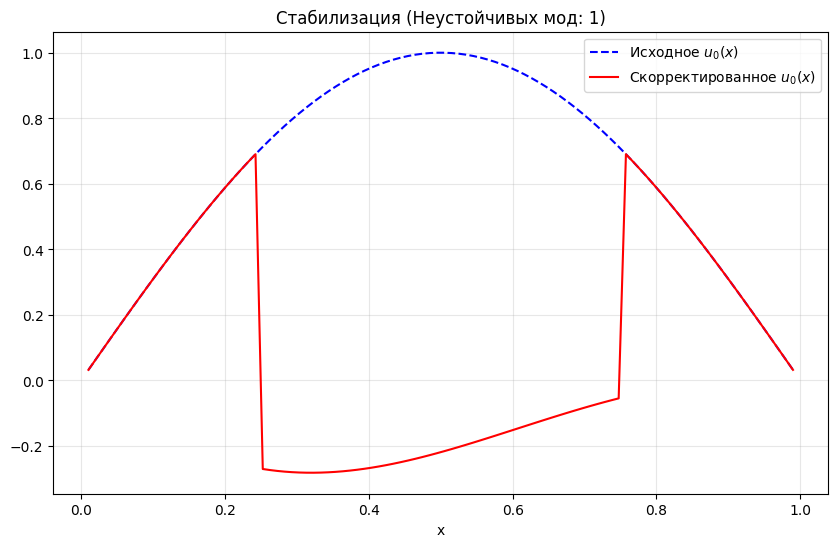

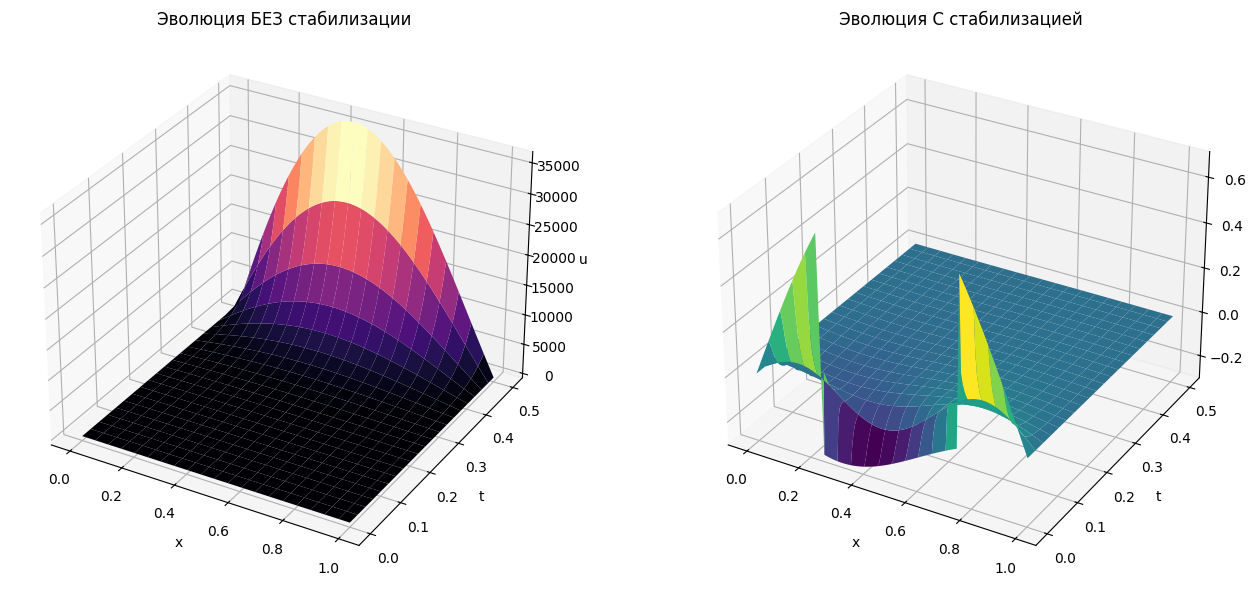

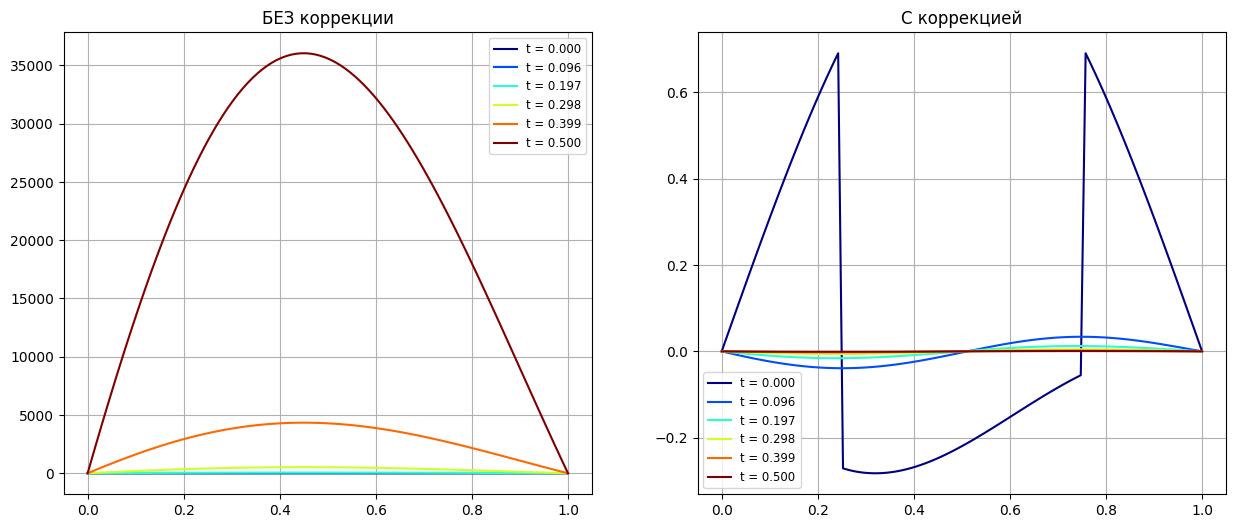

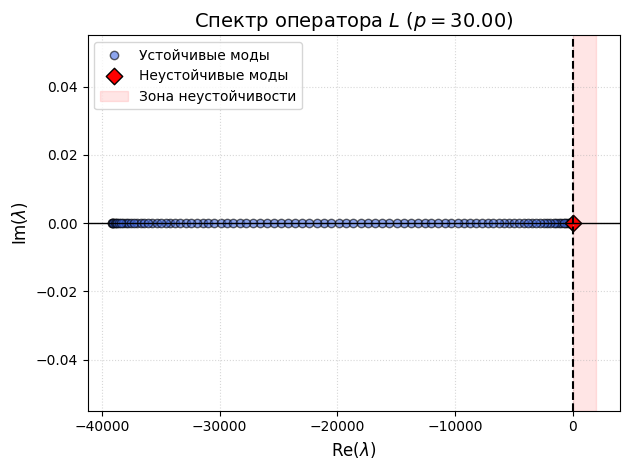

In [2]:
import numpy as np
from scipy.linalg import eig, solve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

L = 1.0
T_final = 0.5

N = 100
Nt = 100

a = 1
# p = 5 * np.pi**2 + 1 
# p = np.pi**2 + 3/4
# p=0
# p=100
p=30

x = np.linspace(0, L, N)
t = np.linspace(0, T_final, Nt)

dx = x[1] - x[0]
dt = T_final / (Nt - 1)

chi = ((x[1:-1] >= L/4) & (x[1:-1] <= 3*L/4)).astype(float)
# chi = np.ones_like(x[1:-1])

def u0(x):
    return np.sin(np.pi * x)


n_int = N - 2
main_diag = (-2/dx**2 + p) * np.ones(n_int)
# off_diag_up = (1/dx**2 - a/(2*dx)) * np.ones(n_int-1)   
# off_diag_low = (1/dx**2 + a/(2*dx)) * np.ones(n_int-1) 
off_diag_up = (1/dx**2 + a/(2*dx)) * np.ones(n_int-1)   
off_diag_low = (1/dx**2 - a/(2*dx)) * np.ones(n_int-1)  

L_mat = np.diag(main_diag) + np.diag(off_diag_up, 1) + np.diag(off_diag_low, -1)

vals, psi_all, phi_all = eig(L_mat, left=True, right=True)

ih_uns = [i for i, v in enumerate(vals) if v.real > 1e-8]

print(f'Найдено неустойчивых мод: {len(ih_uns)}')
print(f'Собственные числа: {vals[ih_uns]}')

V_basis = [] 
W_basis = [] 

for i in ih_uns:
    v_curr = phi_all[:, i]
    w_curr = psi_all[:, i]
    
    if abs(vals[i].imag) > 1e-10:

        if vals[i].imag > 0: 
            V_basis.append(v_curr.real)
            V_basis.append(v_curr.imag)
            W_basis.append(w_curr.real)
            W_basis.append(w_curr.imag)
    else:
        V_basis.append(v_curr.real)
        W_basis.append(w_curr.real)

M_count = len(V_basis)
u0_int = u0(x[1:-1])
# print(u0_int)
# print(W_basis)
if M_count > 0:
    # for k in range(M_count):
    #     norm_v = np.linalg.norm(V_basis[k])
    #     norm_w = np.linalg.norm(W_basis[k])
    #     # V_basis[k] /= norm_v
    #     # W_basis[k] /= norm_w

    A_sys = np.zeros((M_count, M_count))
    b_sys = np.zeros(M_count)

    for k in range(M_count):
        b_sys[k] = -np.dot(u0_int, W_basis[k]) 
        for j in range(M_count):
            A_sys[k, j] = np.dot(chi * V_basis[j], W_basis[k])
        
    # print(A_sys, b_sys)
    c = solve(A_sys, b_sys)

    h_correct = np.zeros(n_int)
    for j in range(M_count):
        h_correct += c[j] * chi * V_basis[j]
    
    u0_corrected = u0_int + h_correct
else:
    u0_corrected = u0_int.copy()
    h_correct = np.zeros(n_int)
u0_corrected +=1e-12


print("\nПроверка проекций:")
for i in ih_uns:
    w_check = psi_all[:, i]
    proj_old = np.dot(u0_int, w_check)
    proj_new = np.dot(u0_corrected, w_check)
    
    print(f"Мода {vals[i]:.2f}: Abs амплитуда до = {(proj_old):.2e}, после = {(proj_new):.2e}")


plt.figure(figsize=(10, 6))
plt.plot(x[1:-1], u0_int, label='Исходное $u_0(x)$', linestyle='--', color='blue')
plt.plot(x[1:-1], u0_corrected, label='Скорректированное $u_0(x)$', color='red')
# plt.plot(x[1:-1], h_correct, label='Управление $h(x)$', color='green', alpha=0.5, linestyle=':')
plt.title(f'Стабилизация (Неустойчивых мод: {len(ih_uns)})')
plt.xlabel('x')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
















def solve_system_implicit(initial_u, dt, h, p_coeff, a_coeff, Nt, N_points):
    u_h = np.zeros((Nt, N_points))
    u_h[0, 1:-1] = initial_u
    
    n_int = N_points - 2
    

    main_diag_vec = ((1/dt) + 2/(h**2) - p_coeff) * np.ones(n_int)
    off_up_vec   = (-1/(h**2) - a_coeff/(2*h)) * np.ones(n_int - 1)
    off_low_vec  = (-1/(h**2) + a_coeff/(2*h)) * np.ones(n_int - 1)

    A_time = np.diag(main_diag_vec) + np.diag(off_up_vec, 1) + np.diag(off_low_vec, -1)
            
    for n in range(Nt - 1):
        rhs = u_h[n, 1:-1] / dt
        u_h[n+1, 1:-1] = solve(A_time, rhs)
        
    return u_h

u_history_old = solve_system_implicit(u0_int, dt, dx, p, a, Nt, N)
u_history_new = solve_system_implicit(u0_corrected, dt, dx, p, a, Nt, N)


fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
X_m, T_m = np.meshgrid(x, t)
surf1 = ax1.plot_surface(X_m, T_m, u_history_old, cmap='magma', rstride=5, cstride=5)
ax1.set_title('Эволюция БЕЗ стабилизации')
ax1.set_xlabel('x')
ax1.set_ylabel('t')
ax1.set_zlabel('u')

ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X_m, T_m, u_history_new, cmap='viridis', rstride=5, cstride=5)
ax2.set_title('Эволюция С стабилизацией')
ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_zlabel('u')

plt.tight_layout()
plt.show()

indices = np.linspace(0, Nt - 1, 6, dtype=int)
colors = plt.cm.jet(np.linspace(0, 1, len(indices)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for i, idx in enumerate(indices):
    current_t = t[idx]
    label = f't = {current_t:.3f}'
    ax1.plot(x, u_history_old[idx, :], label=label, color=colors[i])
    ax2.plot(x, u_history_new[idx, :], label=label, color=colors[i])

ax1.set_title('БЕЗ коррекции')
ax1.legend(fontsize='small')
ax1.grid(True)

ax2.set_title('С коррекцией')
ax2.legend(fontsize='small')
ax2.grid(True)

plt.show()




stable_vals = vals[vals.real <= 1e-8]
unstable_vals = vals[vals.real > 1e-8]

plt.scatter(stable_vals.real, stable_vals.imag, 
            color='royalblue', alpha=0.6, edgecolors='k', label='Устойчивые моды')

if len(unstable_vals) > 0:
    plt.scatter(unstable_vals.real, unstable_vals.imag, 
                color='red', s=70, edgecolors='black', marker='D', label='Неустойчивые моды')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

xmin, xmax = plt.xlim()
plt.axvspan(0, xmax if xmax > 0 else 10, color='red', alpha=0.1, label='Зона неустойчивости')

plt.xlabel(r'$\text{Re}(\lambda)$', fontsize=12)
plt.ylabel(r'$\text{Im}(\lambda)$', fontsize=12)
plt.title(f'Спектр оператора $L$ ($p = {p:.2f}$)', fontsize=14)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.axhline(y=0, color='black', linewidth=1)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
vals, psi_all, phi_all = eig(L_mat, left=True, right=True)


In [40]:
# np.dot(psi_all,phi_all)

# np.sum(psi_all[:,0] * phi_all[:,0])
print('биортогональность :',np.dot(psi_all[:,0] , phi_all[:,0]))
print('биортогональность :',np.dot(psi_all[:,0] , phi_all[:,1]))
print('отсутствие ортогональности для левых бф : ',np.dot(psi_all[:,0] , psi_all[:,1]))
print('отсутствие ортогональности для правых бф : ',np.dot(phi_all[:,2] , phi_all[:,3]))
print(vals)


биортогональность : 0.9998366522654196
биортогональность : -1.1768201430700787e-15
отсутствие ортогональности для левых бф :  -0.018010239898351182
отсутствие ортогональности для правых бф :  0.019847134601305775
[-3.91641287e+04+0.j -3.91345323e+04+0.j -3.90852381e+04+0.j
 -3.90162958e+04+0.j -3.89277746e+04+0.j -3.88197639e+04+0.j
 -3.86923722e+04+0.j -3.85457280e+04+0.j -3.83799789e+04+0.j
 -3.81952917e+04+0.j -3.79918524e+04+0.j -3.77698659e+04+0.j
 -3.75295557e+04+0.j -3.72711637e+04+0.j -3.69949502e+04+0.j
 -3.67011933e+04+0.j -3.63901887e+04+0.j -3.60622496e+04+0.j
 -3.57177063e+04+0.j -3.53569056e+04+0.j -3.49802108e+04+0.j
 -3.45880013e+04+0.j -3.41806719e+04+0.j -3.37586328e+04+0.j
 -3.33223090e+04+0.j -3.28721398e+04+0.j -3.24085785e+04+0.j
 -3.19320918e+04+0.j -3.14431596e+04+0.j -3.09422741e+04+0.j
 -3.04299397e+04+0.j -2.99066723e+04+0.j -2.93729987e+04+0.j
 -2.88294564e+04+0.j -2.82765926e+04+0.j -2.77149640e+04+0.j
 -2.71451362e+04+0.j -2.65676828e+04+0.j -2.59831854e+0

In [121]:
u_history_new[0]

array([ 0.        ,  0.03172793,  0.06342392,  0.09505604,  0.12659245,
        0.1580014 ,  0.18925124,  0.22031053,  0.25114799,  0.28173256,
        0.31203345,  0.34202014,  0.37166246,  0.40093054,  0.42979491,
        0.45822652,  0.48619674,  0.51367739,  0.54064082,  0.56705986,
        0.59290793,  0.61815899,  0.64278761,  0.666769  ,  0.69007901,
       -0.05526881, -0.06097487, -0.06687531, -0.07295784, -0.07920963,
       -0.08561738, -0.09216731, -0.0988452 , -0.10563636, -0.11252572,
       -0.1194978 , -0.12653674, -0.13362635, -0.14075008, -0.14789111,
       -0.15503231, -0.16215632, -0.16924552, -0.17628212, -0.18324812,
       -0.1901254 , -0.19689569, -0.20354064, -0.21004183, -0.21638081,
       -0.2225391 , -0.22849826, -0.2342399 , -0.2397457 , -0.24499746,
       -0.2499771 , -0.25466674, -0.25904869, -0.26310548, -0.26681991,
       -0.27017507, -0.27315439, -0.27574161, -0.2779209 , -0.27967681,
       -0.28099434, -0.28185897, -0.28225665, -0.28217389, -0.28